In [ ]:

!pip install -q transformers torch pandas scikit-learn seaborn matplotlib sentencepiece tiktoken

import os
from google.colab import files

print("Please upload the following 5 files:")
print("1. baseline_defender_weights.pt")
print("2. kantian_defender_weights.pt")
print("3. advanced_attacker_weights.pt")
print("4. probs_retain.npy")
print("5. probs_forget.npy\n")

uploaded = files.upload()
print("\n✅ All files uploaded successfully!")

Please upload the following 5 files:
1. baseline_defender_weights.pt
2. kantian_defender_weights.pt
3. advanced_attacker_weights.pt
4. probs_retain.npy
5. probs_forget.npy



Saving advanced_attacker_weights.pt to advanced_attacker_weights.pt
Saving baseline_defender_weights.pt to baseline_defender_weights.pt
Saving kantian_defender_weights.pt to kantian_defender_weights.pt

✅ All files uploaded successfully!


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



df = pd.read_csv('mtsamples.csv')
df = df.dropna(subset=['transcription', 'medical_specialty'])

top_5 = df['medical_specialty'].value_counts().nlargest(5).index
df = df[df['medical_specialty'].isin(top_5)]

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['medical_specialty'])

# 1.  Test/Train Split (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# 2.  Retain/Forget Split (90/10 of Train)
train_retain_df, train_forget_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])

print(f"✅ Data perfectly reconstructed.")
print(f"Retain Set: {len(train_retain_df)} | Forget Set: {len(train_forget_df)} | Test Set: {len(test_df)}")

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



df = pd.read_csv('mtsamples.csv')
df = df.dropna(subset=['transcription', 'medical_specialty'])

# Only the top 5 specialties to match your num_classes=5
top_5 = df['medical_specialty'].value_counts().nlargest(5).index
df = df[df['medical_specialty'].isin(top_5)]

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['medical_specialty'])

# 1.  Test/Train Split (80/20)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# 2.  Retain/Forget Split (90/10 of Train)
train_retain_df, train_forget_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])

print(f"✅ Data perfectly reconstructed.")
print(f"Retain Set: {len(train_retain_df)} | Forget Set: {len(train_forget_df)} | Test Set: {len(test_df)}")

✅ Data perfectly reconstructed.
Retain Set: 1873 | Forget Set: 209 | Test Set: 521


In [ ]:

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

class ClinicalDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(str(self.texts[idx]), truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(), 'attention_mask': enc['attention_mask'].squeeze(), 'labels': torch.tensor(self.labels[idx])}

train_retain_loader = DataLoader(ClinicalDataset(train_retain_df['transcription'], train_retain_df['label']), batch_size=16, shuffle=True)
train_forget_loader = DataLoader(ClinicalDataset(train_forget_df['transcription'], train_forget_df['label']), batch_size=16, shuffle=False)
test_loader = DataLoader(ClinicalDataset(test_df['transcription'], test_df['label']), batch_size=16, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ DataLoaders ready. Using device: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

✅ DataLoaders ready. Using device: cuda


In [ ]:

import torch.nn as nn
from transformers import BertForSequenceClassification

num_classes = 5

class ThesisAttacker(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_classes + 1, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, logits, entropy):
        return self.net(torch.cat((logits, entropy), dim=1))

# Load Baseline
defender_baseline = BertForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
defender_baseline.load_state_dict(torch.load('baseline_defender_weights.pt', map_location=device))
defender_baseline.eval()

# Load Kantian
defender_kantian = BertForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)
defender_kantian.load_state_dict(torch.load('kantian_defender_weights.pt', map_location=device))
defender_kantian.eval()

# Load Attacker
attacker = ThesisAttacker(num_classes).to(device)
attacker.load_state_dict(torch.load('advanced_attacker_weights.pt', map_location=device))
attacker.eval()

print("✅ All pre-trained weights loaded into memory.")

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

✅ All pre-trained weights loaded into memory.


In [ ]:

from sklearn.metrics import f1_score
import torch.nn.functional as F
import numpy as np

def evaluate_model_comprehensive(model, name):
    print(f"\nEvaluating {name}...")
    model.eval()

    # 1. Test F1 (Diagnostic Utility)
    test_preds, test_true = [], []
    with torch.no_grad():
        for b in test_loader:
            logits = model(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
            test_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            test_true.extend(b['labels'].cpu().numpy())
    test_f1 = f1_score(test_true, test_preds, average='macro', zero_division=0)

    # 2. Forget F1 (Task Accuracy on Unlearned Data)
    forget_preds, forget_true, forget_mia_probs = [], [], []
    with torch.no_grad():
        for b in train_forget_loader:
            logits = model(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
            forget_preds.extend(torch.argmax(logits, 1).cpu().numpy())
            forget_true.extend(b['labels'].cpu().numpy())

            # 3. MIA Risk on Forget Set
            probs = F.softmax(logits, dim=1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=1, keepdim=True)

            mia_scores = attacker(logits, entropy).cpu().numpy().flatten()
            forget_mia_probs.extend(mia_scores)

    forget_f1 = f1_score(forget_true, forget_preds, average='macro', zero_division=0)
    mia_risk = np.mean(forget_mia_probs)

    print(f"Test F1: {test_f1:.4f} | Forget F1: {forget_f1:.4f} | MIA Risk: {mia_risk:.4f}")
    return {"Test F1": test_f1, "Forget F1": forget_f1, "MIA Risk": mia_risk, "forget_mia_dist": forget_mia_probs}

results = {}
results["Baseline"] = evaluate_model_comprehensive(defender_baseline, "Baseline (Gradient Ascent)")
results["Kantian (λ=50)"] = evaluate_model_comprehensive(defender_kantian, "Kantian (λ=50)")


Evaluating Baseline (Gradient Ascent)...
Test F1: 0.5322 | Forget F1: 0.6074 | MIA Risk: 0.5178

Evaluating Kantian (λ=50)...
Test F1: 0.4824 | Forget F1: 0.5311 | MIA Risk: 0.4979


In [ ]:

import torch.optim as optim

print("Training Gold Standard Model (Retrain on Retain Set ONLY)...")
defender_gold = BertForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=num_classes).to(device)

optimizer = optim.AdamW(defender_gold.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

defender_gold.train()
for epoch in range(5):
    total_loss = 0
    for b in train_retain_loader:
        optimizer.zero_grad()
        labels = b['labels'].to(device)
        logits = defender_gold(input_ids=b['input_ids'].to(device), attention_mask=b['attention_mask'].to(device)).logits
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/5 - Retain Loss: {total_loss/len(train_retain_loader):.4f}")

# Save Gold Standard Weights
torch.save(defender_gold.state_dict(), 'gold_standard_weights.pt')

# Evaluate Gold Standard
results["Gold Standard"] = evaluate_model_comprehensive(defender_gold, "Gold Standard (Retrain)")

Training Gold Standard Model (Retrain on Retain Set ONLY)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch 1/5 - Retain Loss: 1.0087
Epoch 2/5 - Retain Loss: 0.6326
Epoch 3/5 - Retain Loss: 0.5142
Epoch 4/5 - Retain Loss: 0.4654
Epoch 5/5 - Retain Loss: 0.4386

Evaluating Gold Standard (Retrain)...
Test F1: 0.5484 | Forget F1: 0.5555 | MIA Risk: 0.4925



--- KOLMOGOROV-SMIRNOV STATISTICAL TEST ---
K-S Statistic: 0.2632
P-Value: 0.0000
⚠️ CONCLUSION: Distributions differ significantly.


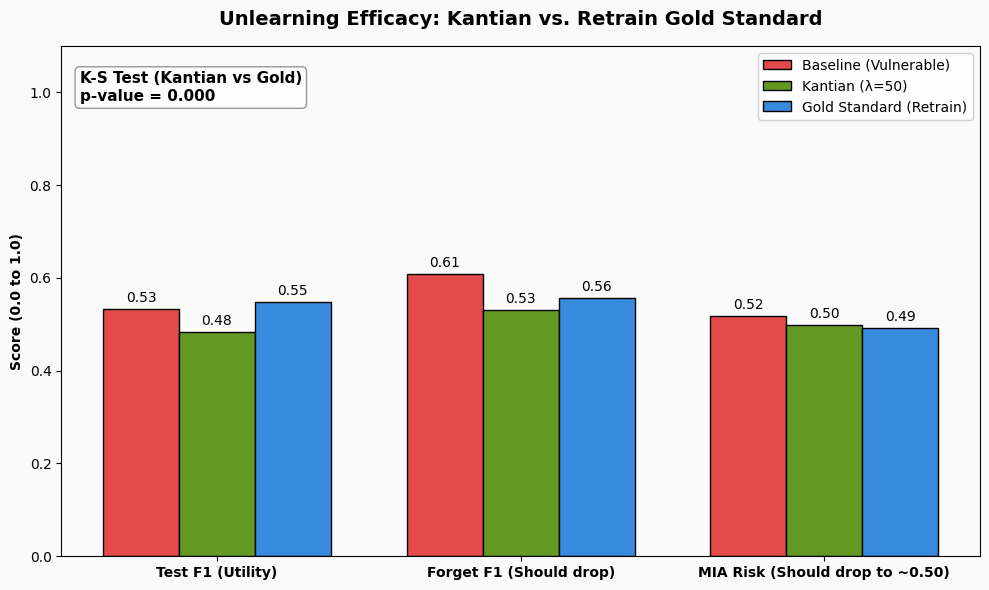

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

# 1. Kolmogorov-Smirnov (K-S) Test
# We test if the MIA distribution of Kantian matches the Gold Standard
kantian_dist = results["Kantian (λ=50)"]["forget_mia_dist"]
gold_dist = results["Gold Standard"]["forget_mia_dist"]

ks_stat, p_value = ks_2samp(kantian_dist, gold_dist)
print(f"\n--- KOLMOGOROV-SMIRNOV STATISTICAL TEST ---")
print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-Value: {p_value:.4f}")
if p_value > 0.05:
    print("✅ CONCLUSION: The Kantian unlearning distribution is STATISTICALLY INDISTINGUISHABLE from the Retrain Gold Standard.")
else:
    print("⚠️ CONCLUSION: Distributions differ significantly.")

# 2. Comparative Bar Chart (The Money Shot)
labels = ['Test F1 (Utility)', 'Forget F1 (Should drop)', 'MIA Risk (Should drop to ~0.50)']
baseline_metrics = [results["Baseline"]["Test F1"], results["Baseline"]["Forget F1"], results["Baseline"]["MIA Risk"]]
kantian_metrics = [results["Kantian (λ=50)"]["Test F1"], results["Kantian (λ=50)"]["Forget F1"], results["Kantian (λ=50)"]["MIA Risk"]]
gold_metrics = [results["Gold Standard"]["Test F1"], results["Gold Standard"]["Forget F1"], results["Gold Standard"]["MIA Risk"]]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

rects1 = ax.bar(x - width, baseline_metrics, width, label='Baseline (Vulnerable)', color='#E24B4A', edgecolor='black')
rects2 = ax.bar(x, kantian_metrics, width, label='Kantian (λ=50)', color='#639922', edgecolor='black')
rects3 = ax.bar(x + width, gold_metrics, width, label='Gold Standard (Retrain)', color='#378ADD', edgecolor='black')

ax.set_ylabel('Score (0.0 to 1.0)', fontweight='bold')
ax.set_title('Unlearning Efficacy: Kantian vs. Retrain Gold Standard', fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

autolabel(rects1); autolabel(rects2); autolabel(rects3)

#  P-value text box to chart
textstr = f'K-S Test (Kantian vs Gold)\np-value = {p_value:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props, fontweight='bold')

plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('Thesis_Gold_Standard_Comparison.png', dpi=300)
plt.show()

df_results = pd.DataFrame(results).T.drop(columns=["forget_mia_dist"])
df_results.to_csv('Thesis_Final_Validation_Metrics.csv')